# Stability of Rankings LIME vs SHAP
This notebook will try and investigate the differences in the stability of the rankings produced by the two methods  

**Conclusion**  
The instability is not as present as I thought it was. It is a dangerous topic, since the rankings are so dependend on what features are demmed important initially and the features that are suppressed. We do indded see considerable more cases where a change in p-value occurs for the same dataset when considering LIME, showing that lime is indeed more unstable. The same happens for SHAP but not to the same extent at all.  
There is two kinds of stability: 
* We expecte same result if we give same input. LIME is defintetly much worse at this than SHAP. See t closeness of adult and usa house. and k anonymity of usa house

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["adult","usa_house","usa_house_old", "cervic_cancer", "adult_imbalanced", "old_adult"],
    "../data/",
)

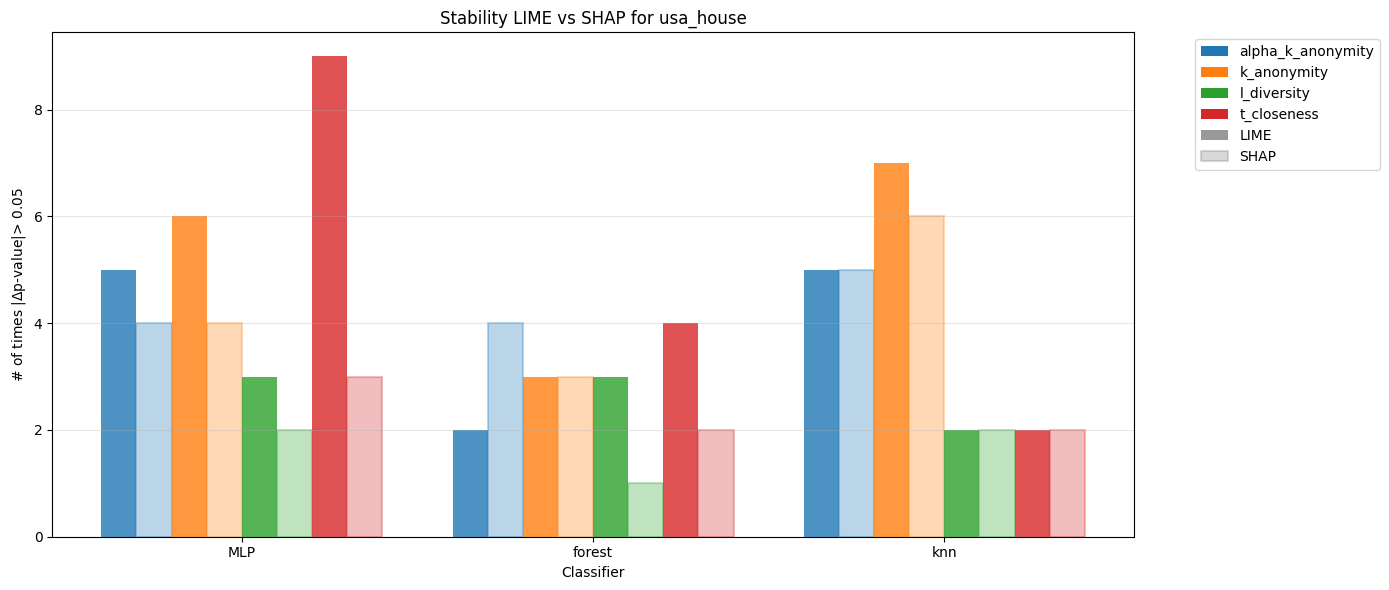

In [10]:
pl.plot_histogram("usa_house", threshold=0.05)

This shows that LIME produces rankings that tend to to change more times. Note, here we are looking at the amount of times the pvalue changes with more than 0.05. 5% has been chosen becaue it is often used in the litterature for significance measuring. If there is a p-value of 0, such a change would make the correlation not significant. To sum it up, as the dataset is generalized more, SHAP tends to produce rankings that vary fewer times
Some anonymization models produce rather constatn datasets. Consider the plot below

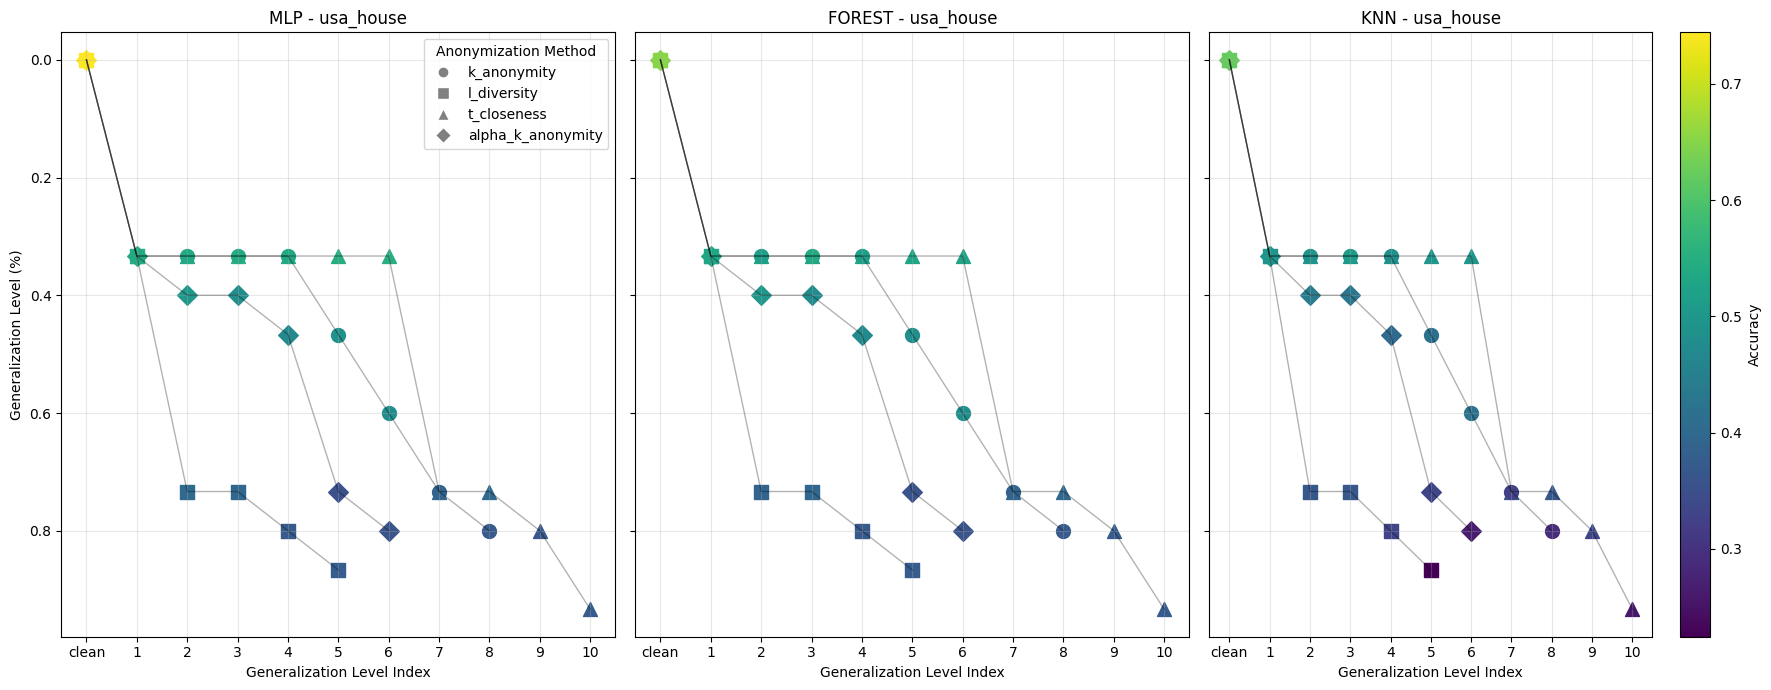

In [4]:
pl.plot_utility("usa_house", ["MLP", "forest", "knn"])

Note how k_anonymity and t_closeness stays at the same generalization level for some time. Note that t_closeness is generalized four times, but the LIME produced rank changes a lot more for MLP. It is more unstable for that classifier. 

Let us consider how MLP compares with the other plots, because it looks quite a bit more unstable compared to the other ones

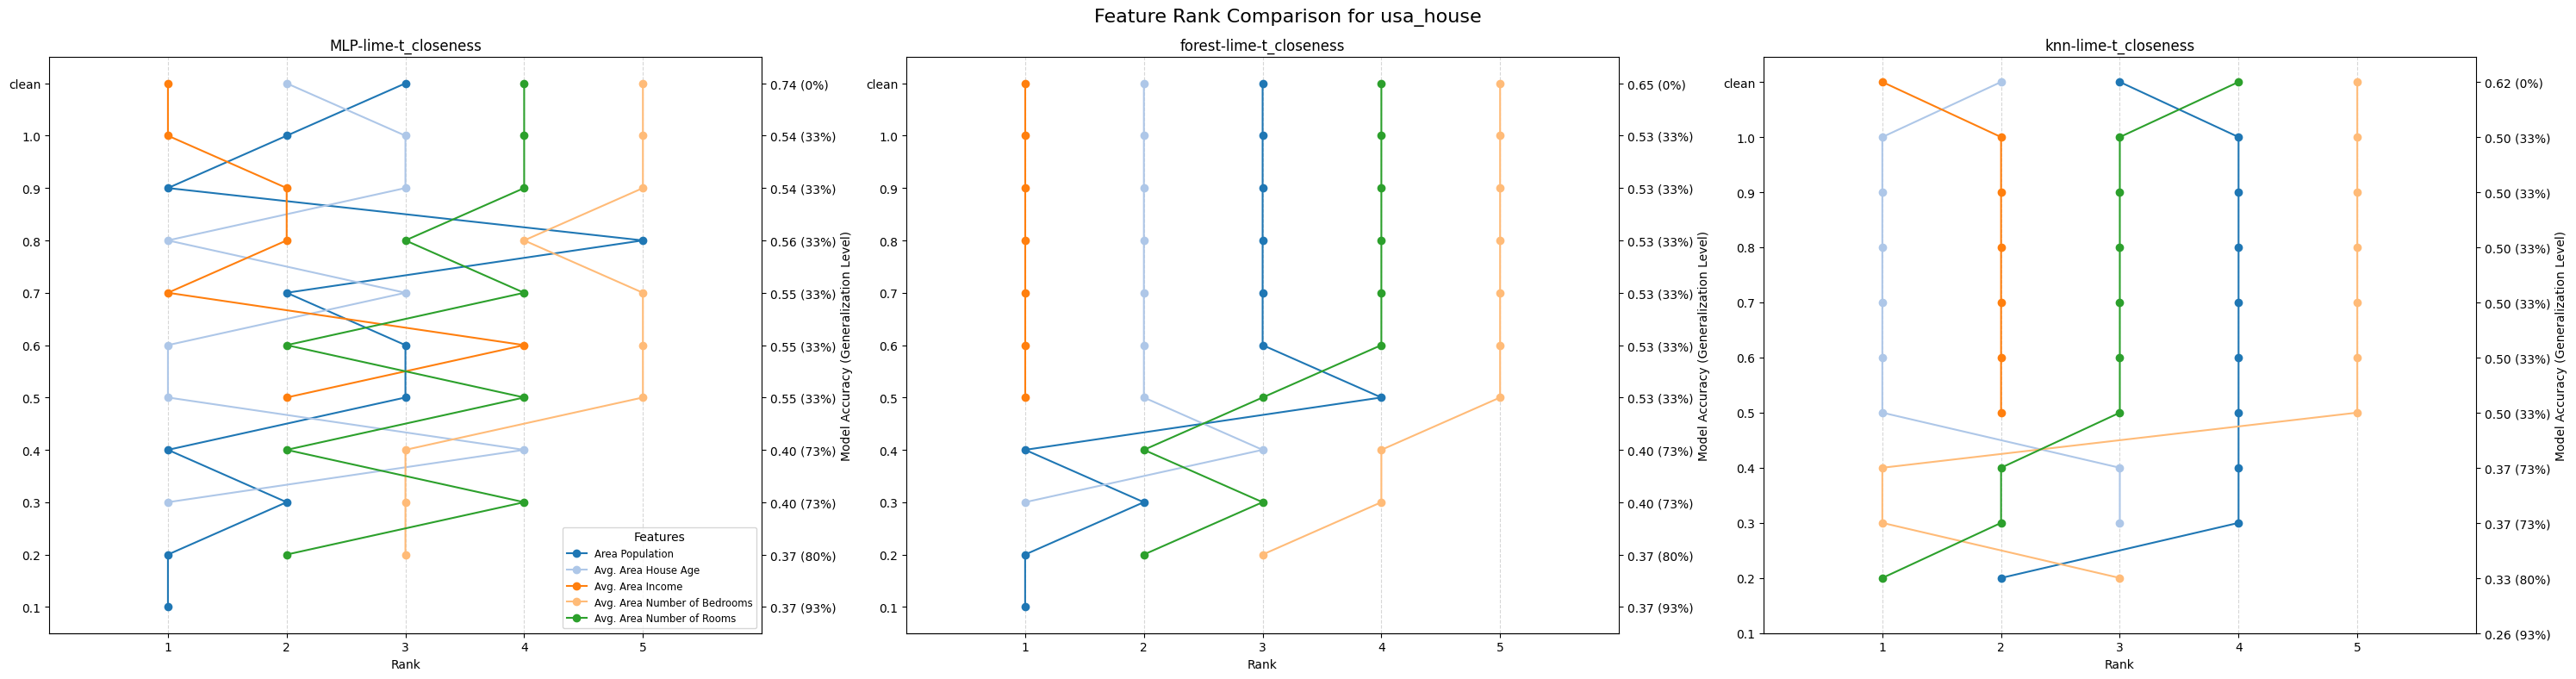

In [4]:
pl.plot_line_compare("usa_house", ["MLP-lime-t_closeness", "forest-lime-t_closeness", "knn-lime-t_closeness"])

As expected, the MLP model is much more unstable. The usa house has between 4000 and 5000 points in it after anonymization, and for each LIME explanation at least 150000 points are used, i.e. all the points are used every time. The fact that the rankings look different probably comes down to the fact that the 1000 representative explanations used are different for every dataset

Now let us consider the adult dataset. Here we only have two anonymization models that make sense because it is a binary classificaiton problem

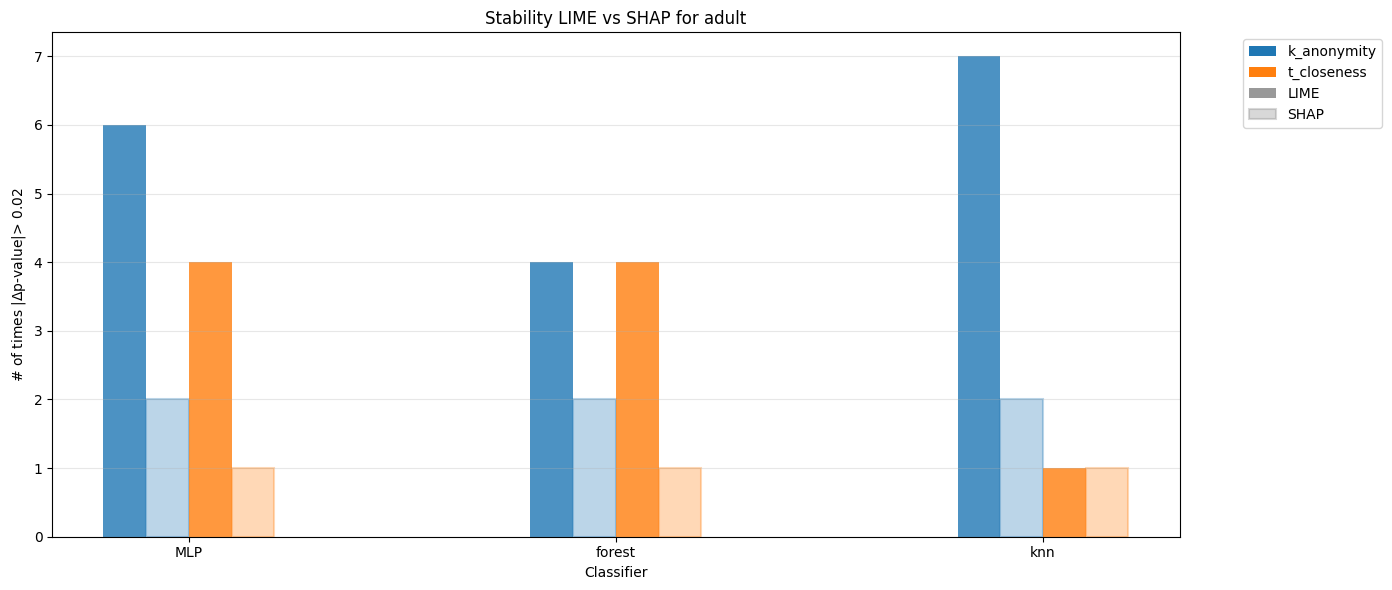

In [26]:
pl.plot_histogram("adult", threshold=0.02, anon_models=["t_closeness","k_anonymity"])

Note, in t_closeness we only see two major changes in the topology, so we would expect to see a maximum of 2 differences in the histogram. But here it is much higher for LIME in most of the cases, indicating instability. As for the k anonymity, there the features are suppressed slowly one by one justifying. We would expect that the difference was higher here, but it is not. It can come down to the fact that as more features are suppressed, they become more aggreable with the initial ranking even though they change the rankings of other features

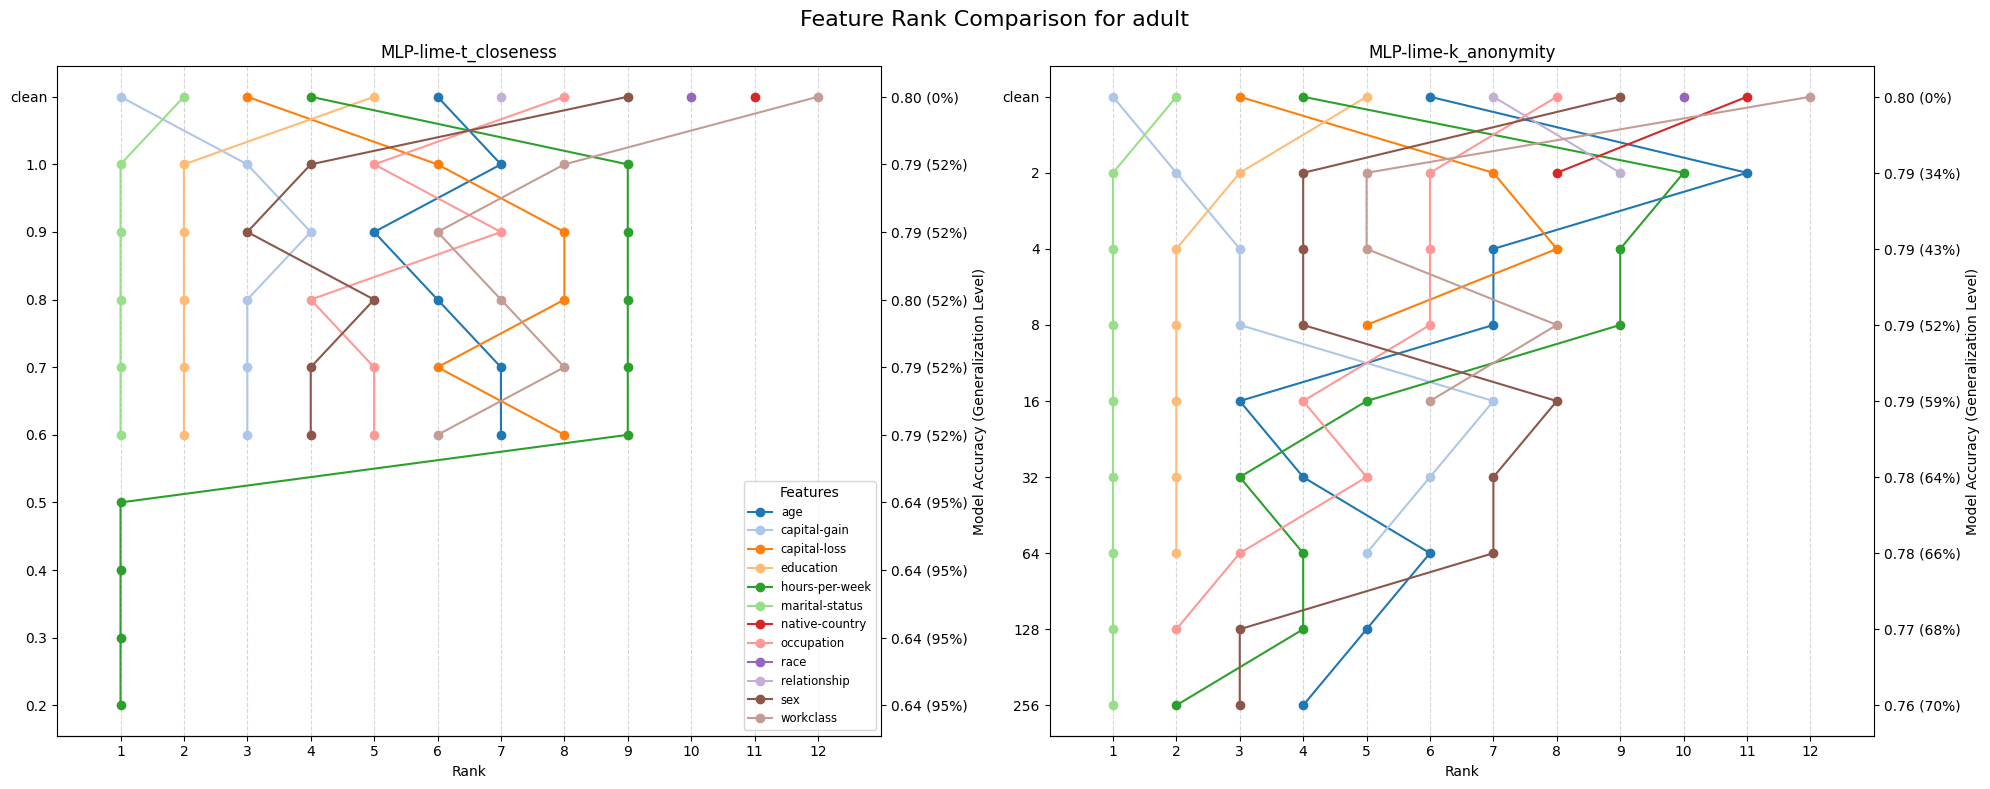

In [29]:
pl.plot_line_compare("adult", ["MLP-lime-t_closeness", "MLP-lime-k_anonymity"])

Below we consider the cervic cancer dataset. We see that we canont really draw any conclusiosn from it. The only one that makes sense is the t_closenss and that is quite stable actually. While the rankings do changes, they do not change significantly

Let us consider another dataset. Note, this dataset is the only dataset that was allow to suppress 30% of it's instances. Here we will only consider t_closeness since it is the only anonymizatino method that produces rankings that can meaningfully compare stability for. The other anonymizaiton models produce topologies where too many features are constantly suppressed

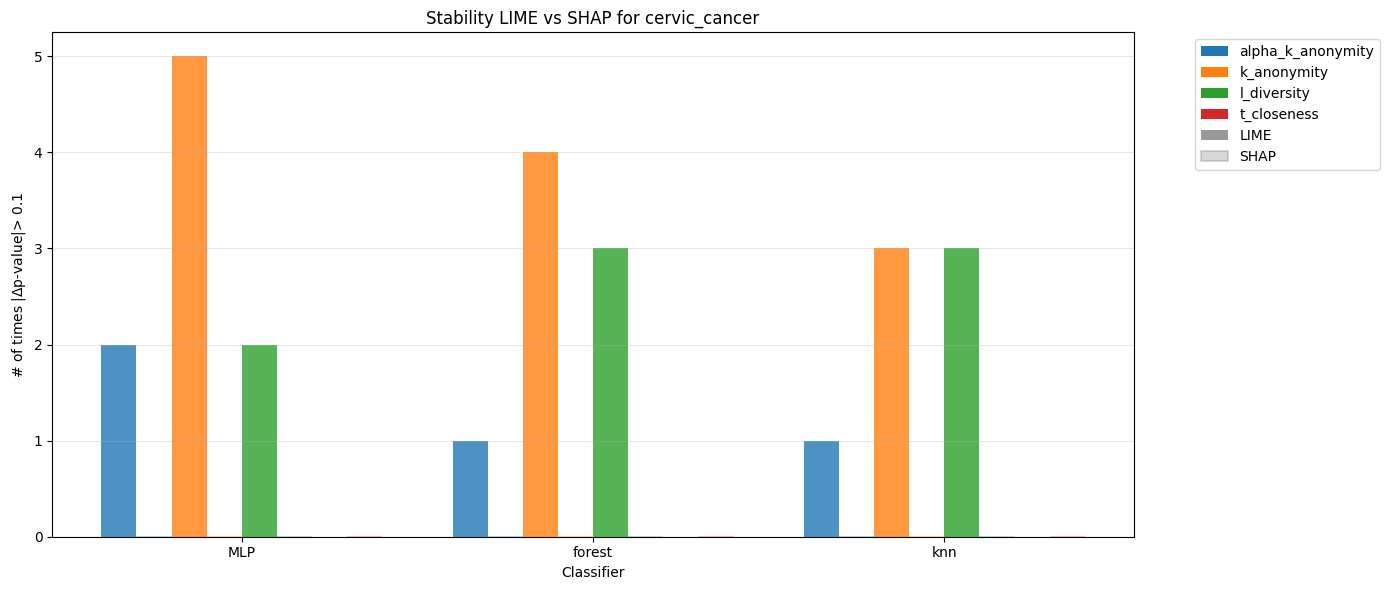

In [16]:
pl.plot_histogram("cervic_cancer",threshold=0.1)

This plot is slighly different compared to the first one. Here the ranking of the clean dataset is omitted and everything is compared to the ranking of the second anonymized dataset. Note also that the threshold has changed. Note, in this case, there is really only one change in the dataset, so we would expect to see at most one. Forest produces none due to the randomness of the initial ranking. MLP produces 3 which is more than 1. This again show that LIME is unstable even when using the same dataset as input. 

Below we can see that t_closeness produces a lot of similar datasets

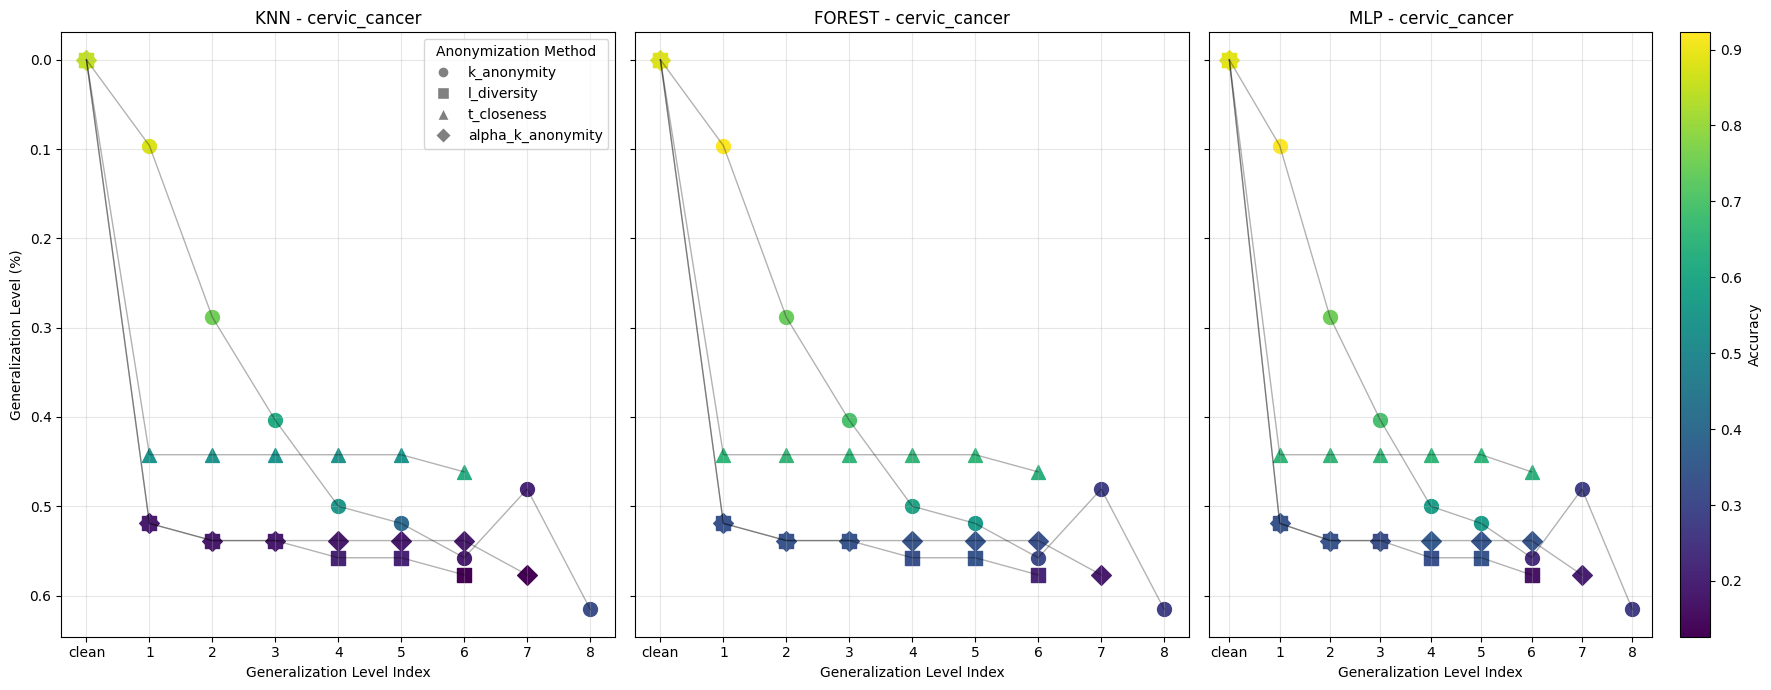

In [3]:
pl.plot_utility("cervic_cancer")